In [15]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
import numpy as np
from qiskit_ibm_runtime.fake_provider import FakeFez
from qiskit.quantum_info import Statevector, state_fidelity, partial_trace

backend = FakeFez()
#Credits to: https://qiskit.github.io/qiskit-aer/tutorials/2_device_noise_simulation.html

Results (Format: 'data syndrome'): {'0 11': 6133, '1 11': 2059}


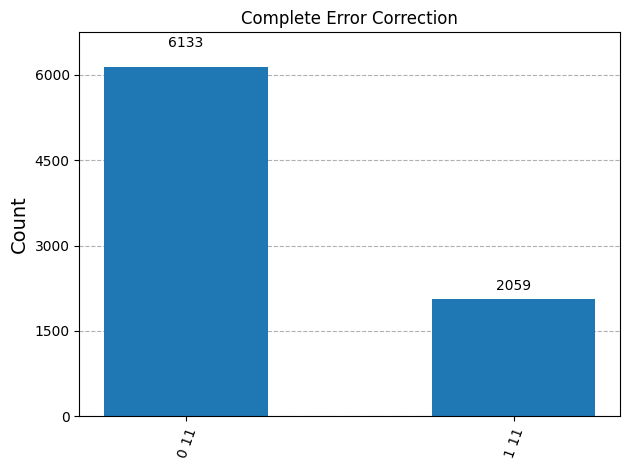

In [16]:
# 1. Register definition
q = QuantumRegister(3, 'q')
c_syndrome = ClassicalRegister(2, 'syndrome')
c_data = ClassicalRegister(1, 'data') 
circ = QuantumCircuit(q, c_syndrome, c_data, name = "Phase Flip Code")


# 2. Initialization (Probabilities 3/4 and 1/4)
theta = np.pi / 3
circ.ry(theta, 0)


# 3. Logical qubit encoding
circ.cx(0, 1)
circ.cx(0, 2)
circ.h(0)  # Apply H to prepare for phase flip error injection
circ.h(1)
circ.h(2)
circ.barrier()

# 4. Error injection
circ.z(0)
circ.barrier()

# 5. Decoding
circ.h(0)
circ.h(1)
circ.h(2)
circ.cx(0, 2)
circ.cx(0, 1)
circ.barrier()

circ.measure([1, 2], c_syndrome)  # Measure the syndrome into the classical register

# 7. CONDITIONAL CORRECTION (Dynamic circuits)
# The condition is passed as a tuple: (classical_register, decimal_value)

with circ.if_test((c_syndrome, 3)):
    circ.x(0)  # If it measures '11' , correct q0
circ.barrier()
# 8. Final DATA measurement
circ.measure([0], c_data)     

# 9. Execution on the simulator
sim_ideal = AerSimulator()
result = sim_ideal.run(transpile(circ, sim_ideal), shots=8192).result()
counts = result.get_counts(circ)

print("Results (Format: 'data syndrome'):", counts)   
plot_histogram(counts, title='Complete Error Correction')
#circ.draw('mpl')

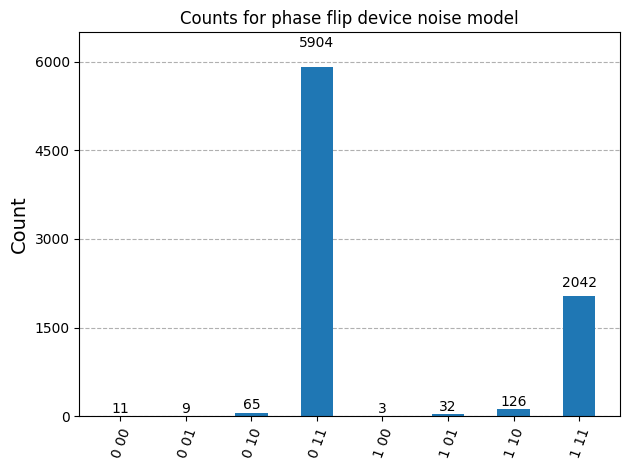

In [17]:
#Using the noise model from the fake Vigo device


noise = NoiseModel.from_backend(backend) 
#From mumbai backends we just extract the noise model, 
#so we can apply conditional corrections in the circuit, which is not possible when we execute directly on the backend, 
# #as it does not support dynamic circuits.
sim_noise = AerSimulator(noise_model = noise)



# Transpile the circuit for the noisy basis gates
tcirc = transpile(circ, sim_noise)

# Execute noisy simulation and get counts
result_noise = sim_noise.run(tcirc, shots=8192).result()
counts_noise = result_noise.get_counts(0)
plot_histogram(counts_noise,
               title="Counts for phase flip device noise model")

# Tomography for Z component

In [18]:
# 1. Register definition
q = QuantumRegister(3, 'q')
c_syndrome = ClassicalRegister(2, 'syndrome')
c_data = ClassicalRegister(1, 'data') 
circ_z = QuantumCircuit(q, c_syndrome, c_data, name = "Phase Flip Code Z Tomography")

# 2. Initialization (Probabilities 3/4 and 1/4)
theta = np.pi / 3
circ_z.ry(theta, 0)
# 3. Logical qubit encoding
circ_z.cx(0, 1)
circ_z.cx(0, 2)
circ_z.barrier()
# 4. Error injection
circ_z.x(0)
circ_z.barrier()
# 5. Decoding
circ_z.cx(0, 1)
circ_z.cx(0, 2)
circ_z.barrier()

# 6. Exclusive SYNDROME measurement
circ_z.measure([1, 2], c_syndrome) 
circ_z.barrier()

#6. Conditional Correction


with circ_z.if_test((c_syndrome, 3)):
    circ_z.x(0)  # If it measures '11' , correct q0

#For errors on q1 or q2, the correction is not applied cause q0 maintains without error.
circ_z.barrier()

#7. Tomography measurements for Z component
circ_z.measure([0], c_data)
circ_z.barrier()




# 6. Execution on the simulator
sim_ideal = AerSimulator()
result_z = sim_ideal.run(transpile(circ_z, sim_ideal), shots=8192).result()
counts_z = result_z.get_counts(circ_z)
print("Results (Format: 'data syndrome'):", counts_z)
fig1 = plot_histogram(counts_z, title='Tomography for Z component for phaseflip code')
fig1.savefig('Tomography_comp_Z_phaseflip.png')


Results (Format: 'data syndrome'): {'0 11': 6144, '1 11': 2048}


# Tomography for Z component at noisy model

In [19]:
# Transpile the circuit for the noisy basis gates
tcirc_z = transpile(circ_z, sim_noise)

# Execute noisy simulation and get counts
result_noise_z = sim_noise.run(tcirc_z, shots=8192).result()
counts_noise_z = result_noise_z.get_counts(0)
fig2 = plot_histogram(counts_noise_z,
               title="Tomography for Z component at noise model for phaseflip code")
fig2.savefig('Tomography_comp_Z_phaseflip_noisy.png')

# Tomography for X component

In [20]:
# TOMOGRAFÍA PARA LA COMPONENTE Z

# 1. Register definition
q = QuantumRegister(3, 'q')
c_syndrome = ClassicalRegister(2, 'syndrome')
c_data = ClassicalRegister(1, 'data') 
circ_x = QuantumCircuit(q, c_syndrome, c_data, name = "Phase Flip Code X Tomography")

# 2. Initialization (Probabilities 3/4 and 1/4)
theta = np.pi / 3
circ_x.ry(theta, 0)
# 3. Logical qubit encoding
circ_x.cx(0, 1)
circ_x.cx(0, 2)
circ_x.barrier()
# 4. Error injection
circ_x.x(0)
circ_x.barrier()
# 5. Decoding
circ_x.cx(0, 1)
circ_x.cx(0, 2)
circ_x.barrier()

# 6. Exclusive SYNDROME measurement
circ_x.measure([1, 2], c_syndrome) 
circ_x.barrier()

#6. Conditional Correction


with circ_x.if_test((c_syndrome, 3)):
    circ_x.x(0)  # If it measures '11' , correct q0

#For errors on q1 or q2, the correction is not applied cause q0 maintains without error.
circ_x.barrier()

#7. Tomography measurements for X component
circ_x.h(0)  # Apply H to measure in X basis
circ_x.measure([0], c_data)
circ_x.barrier()




# 6. Execution on the simulator
sim_ideal = AerSimulator()
result_x = sim_ideal.run(transpile(circ_x, sim_ideal), shots=8192).result()
counts_x = result_x.get_counts(circ_x)
print("Results (Format: 'data syndrome'):", counts_x)
fig3 = plot_histogram(counts_x, title='Tomography for X component for phaseflip code')
fig3.savefig('Tomography_comp_X_phaseflip.png')

Results (Format: 'data syndrome'): {'0 11': 7660, '1 11': 532}


# Tomography for X-component at nosiy model

In [21]:
# Transpile the circuit for the noisy basis gates
tcirc_x = transpile(circ_x, sim_noise)

# Execute noisy simulation and get counts
result_noise_x = sim_noise.run(tcirc_x, shots=8192).result()
counts_noise_x = result_noise_x.get_counts(tcirc_x)
fig4 = plot_histogram(counts_noise_x,
               title="Tomography for X component at noise model for phaseflip code")
fig4.savefig('Tomography_comp_X_phaseflip_noisy.png')

# Tomography for Y-basis

In [22]:
# 1. Register definition
q = QuantumRegister(3, 'q')
c_syndrome = ClassicalRegister(2, 'syndrome')
c_data = ClassicalRegister(1, 'data') 
circ_y = QuantumCircuit(q, c_syndrome, c_data, name = "Phase Flip Code Y Tomography")

# 2. Initialization (Probabilities 3/4 and 1/4)
theta = np.pi / 3
circ_y.ry(theta, 0)
# 3. Logical qubit encoding
circ_y.cx(0, 1)
circ_y.cx(0, 2)
circ_y.barrier()
# 4. Error injection
circ_y.x(0)
circ_y.barrier()
# 5. Decoding
circ_y.cx(0, 1)
circ_y.cx(0, 2)
circ_y.barrier()

# 6. Exclusive SYNDROME measurement
circ_y.measure([1, 2], c_syndrome) 
circ_y.barrier()

#6. Conditional Correction


with circ_y.if_test((c_syndrome, 3)):
    circ_y.x(0)  # If it measures '11' , correct q0

#For errors on q1 or q2, the correction is not applied cause q0 maintains without error.
circ_y.barrier()

#7. Tomography measurements for Y component
circ_y.sdg(0)  # Apply Sdg to measure in Y basis
circ_y.h(0)  
circ_y.measure([0], c_data)
circ_y.barrier()




# 6. Execution on the simulator
sim_ideal = AerSimulator()
result_y = sim_ideal.run(transpile(circ_y, sim_ideal), shots=8192).result()
counts_y = result_y.get_counts(circ_y)
print("Results (Format: 'data syndrome'):", counts_y)
fig5 = plot_histogram(counts_y, title='Tomography for Y component for phaseflip code')
fig5.savefig('Tomography_comp_Y_phaseflip.png')


Results (Format: 'data syndrome'): {'1 11': 4083, '0 11': 4109}


# Tomography for Y-component at noisy model

In [23]:
# Transpile the circuit for the noisy basis gates
tcirc_y = transpile(circ_y, sim_noise)

# Execute noisy simulation and get counts
result_noise_y = sim_noise.run(tcirc_y, shots=8192).result()
counts_noise_y = result_noise_y.get_counts(tcirc_y)
fig6 = plot_histogram(counts_noise_y,
               title="Tomography for Y component at noise model for phaseflip code")
fig6.savefig('Tomography_comp_Y_phaseflip_noisy.png')

# State vector representation at the Bloch sphere

Mean value for Z component: 0.5
Mean value for X component: 0.8701171875
Mean value for Y component: 0.003173828125
Probability conservation (should be close to 1.0): 1.0071139931678772


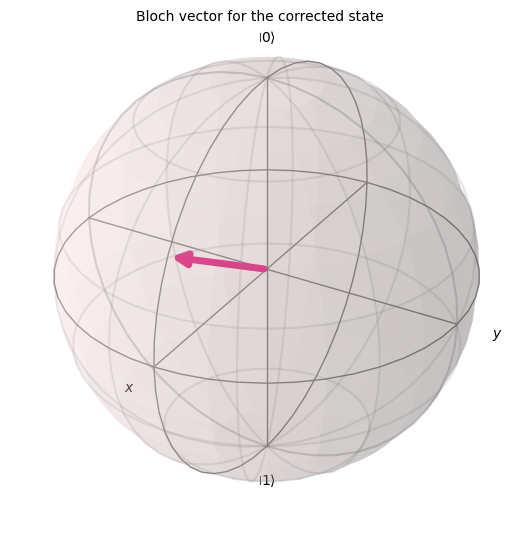

In [24]:
from qiskit.visualization import plot_bloch_vector
import numpy as np

shots = 8192


# Direct extraction and calculation for the Z component

counts_0_z = sum(val for key, val in counts_z.items() if key.startswith('0'))
counts_1_z = sum(val for key, val in counts_z.items() if key.startswith('1'))
mean_z = (counts_0_z - counts_1_z) / shots


# Direct extraction and calculation for the X component

counts_0_x = sum(val for key, val in counts_x.items() if key.startswith('0'))
counts_1_x = sum(val for key, val in counts_x.items() if key.startswith('1'))
mean_x = (counts_0_x - counts_1_x) / shots


# Direct extraction and calculation for the Y component

counts_0_y = sum(val for key, val in counts_y.items() if key.startswith('0'))
counts_1_y = sum(val for key, val in counts_y.items() if key.startswith('1'))
mean_y = (counts_0_y - counts_1_y) / shots

# Print the results
print(f"Mean value for Z component: {mean_z}")
print(f"Mean value for X component: {mean_x}")
print(f"Mean value for Y component: {mean_y}")

# Verify probability conservation
prob = mean_x ** 2 + mean_y ** 2 + mean_z ** 2
print(f"Probability conservation (should be close to 1.0): {prob}")

# Plot the Bloch vector
vector = np.array([mean_x, mean_y, mean_z])
plot_bloch_vector(vector, title='Bloch vector for the corrected state')

# Noisy bloch sphere representation

Mean value for Z component: 0.479736328125
Mean value for X component: 0.810791015625
Mean value for Y component: 0.01123046875
Probability conservation (should be close to 1.0): 0.8876551389694214


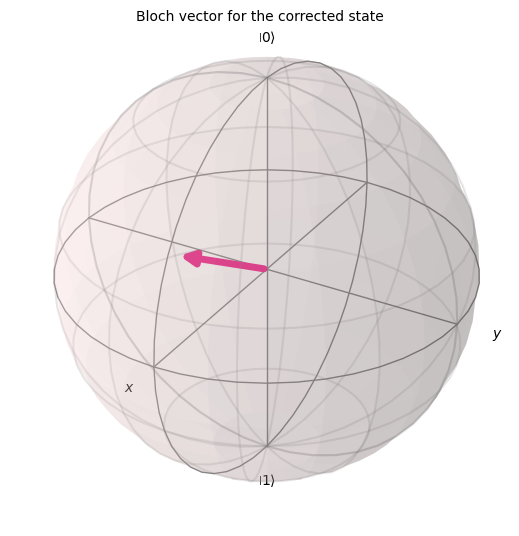

In [25]:
# The Noisy vector state for the initial state used before is:

from qiskit.visualization import plot_bloch_vector
import numpy as np

shots = 8192


# Direct extraction and calculation for the Z component

counts_0_noise_z = sum(val for key, val in counts_noise_z.items() if key.startswith('0'))
counts_1_noise_z = sum(val for key, val in counts_noise_z.items() if key.startswith('1'))
mean_noise_z = (counts_0_noise_z - counts_1_noise_z) / shots


# Direct extraction and calculation for the X component

counts_0_noise_x = sum(val for key, val in counts_noise_x.items() if key.startswith('0'))
counts_1_noise_x = sum(val for key, val in counts_noise_x.items() if key.startswith('1'))
mean_noise_x = (counts_0_noise_x - counts_1_noise_x) / shots


# Direct extraction and calculation for the Y component

counts_0_noise_y = sum(val for key, val in counts_noise_y.items() if key.startswith('0'))
counts_1_noise_y = sum(val for key, val in counts_noise_y.items() if key.startswith('1'))
mean_noise_y = (counts_0_noise_y - counts_1_noise_y) / shots

# Print the results
print(f"Mean value for Z component: {mean_noise_z}")
print(f"Mean value for X component: {mean_noise_x}")
print(f"Mean value for Y component: {mean_noise_y}")

# Verify probability conservation
prob = mean_noise_x ** 2 + mean_noise_y ** 2 + mean_noise_z ** 2
print(f"Probability conservation (should be close to 1.0): {prob}")

# Plot the Bloch vector
vector = np.array([mean_noise_x, mean_noise_y, mean_noise_z])
plot_bloch_vector(vector, title='Bloch vector for the corrected state')

# Calculating the fidelity of the state

In [26]:
# Density matrix reconstruction from the measured Bloch vector components
rho_reconstructed = 0.5 * (
    np.eye(2) +
    mean_x * np.array([[0,1],[1,0]]) +
    mean_y * np.array([[0,-1j],[1j,0]]) +
    mean_z * np.array([[1,0],[0,-1]])
)

# Ideal state as a density matrix vector
ideal = np.array([np.sqrt(3)/2, 1/2])
rho_ideal = np.outer(ideal, ideal)

# Fidelidad F = Tr(rho_ideal @ rho_reconstructed)
# Para estado puro: F = <psi|rho|psi>
fidelity = np.real(np.trace(rho_ideal @ rho_reconstructed))
print(f"Fidelidad reconstruida: {fidelity:.6f}")

Fidelidad reconstruida: 1.001772


# Calculating the fidelity of the state for the noisy model

In [27]:
# Density matrix reconstruction from the measured Bloch vector components
rho_reconstructed = 0.5 * (
    np.eye(2) +
    mean_noise_x * np.array([[0,1],[1,0]]) +
    mean_noise_y * np.array([[0,-1j],[1j,0]]) +
    mean_noise_z * np.array([[1,0],[0,-1]])
)

# Ideal state as a density matrix vector
ideal = np.array([np.sqrt(3)/2, 1/2])
rho_ideal = np.outer(ideal, ideal)

# Fidelidad F = Tr(rho_ideal @ rho_reconstructed)
# Para estado puro: F = <psi|rho|psi>
fidelity = np.real(np.trace(rho_ideal @ rho_reconstructed))
print(f"Fidelidad reconstruida: {fidelity:.6f}")

Fidelidad reconstruida: 0.971017
